# Phase 4 — Baseline Modeling

## Uncertainty-Aware Material Selection using Machine Learning

### Objective

Establish baseline regression performance for predicting the
Voigt-Reuss-Hill bulk modulus (`K_VRH`).

The purpose of this phase is to create reliable reference models before
introducing more advanced modeling or uncertainty estimation.

### Target

- `K_VRH`: Voigt-Reuss-Hill bulk modulus (GPa)

### Evaluation Metrics

- MAE — Mean Absolute Error
- RMSE — Root Mean Squared Error
- R² — Coefficient of Determination

### Data Strategy

- Training set: model fitting
- Validation set: model comparison and development decisions
- Test set: kept untouched until final model evaluation

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor

In [2]:
df = pd.read_csv("../data/processed/clean_materials_data.csv")

X = df.drop(columns=["K_VRH"])
y = df["K_VRH"]

df.shape

(1181, 5)

In [3]:
# 80% train, 20% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Temporary set -> 10% validation, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (944, 4) (944,)
Validation: (118, 4) (118,)
Test: (119, 4) (119,)


In [4]:
dummy_model = DummyRegressor(strategy="mean")

dummy_model.fit(X_train, y_train)

y_val_pred_dummy = dummy_model.predict(X_val)

In [5]:
dummy_mae = mean_absolute_error(y_val, y_val_pred_dummy)

dummy_rmse = np.sqrt(
    mean_squared_error(y_val, y_val_pred_dummy)
)

dummy_r2 = r2_score(y_val, y_val_pred_dummy)

print(f"Dummy MAE:  {dummy_mae:.2f} GPa")
print(f"Dummy RMSE: {dummy_rmse:.2f} GPa")
print(f"Dummy R²:   {dummy_r2:.3f}")

Dummy MAE:  61.54 GPa
Dummy RMSE: 76.34 GPa
Dummy R²:   -0.005


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    StandardScaler,
    OneHotEncoder
)
from sklearn.linear_model import LinearRegression

numerical_features = [
    "nsites",
    "volume",
    "elastic_anisotropy"
]

categorical_features = [
    "space_group"
]

numerical_pipeline = Pipeline([
    (
        "log_transform",
        FunctionTransformer(
            np.log1p,
            feature_names_out="one-to-one"
        )
    ),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [7]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

linear_model.fit(X_train, y_train)

y_val_pred_linear = linear_model.predict(X_val)

In [8]:
linear_mae = mean_absolute_error(
    y_val,
    y_val_pred_linear
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        y_val_pred_linear
    )
)

linear_r2 = r2_score(
    y_val,
    y_val_pred_linear
)

print(f"Linear Regression MAE:  {linear_mae:.2f} GPa")
print(f"Linear Regression RMSE: {linear_rmse:.2f} GPa")
print(f"Linear Regression R²:   {linear_r2:.3f}")

Linear Regression MAE:  43.93 GPa
Linear Regression RMSE: 59.17 GPa
Linear Regression R²:   0.397


In [9]:
from sklearn.linear_model import Ridge

ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

y_val_pred_ridge = ridge_model.predict(X_val)

In [10]:
ridge_mae = mean_absolute_error(
    y_val,
    y_val_pred_ridge
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        y_val_pred_ridge
    )
)

ridge_r2 = r2_score(
    y_val,
    y_val_pred_ridge
)

print(f"Ridge MAE:  {ridge_mae:.2f} GPa")
print(f"Ridge RMSE: {ridge_rmse:.2f} GPa")
print(f"Ridge R²:   {ridge_r2:.3f}")

Ridge MAE:  43.70 GPa
Ridge RMSE: 58.36 GPa
Ridge R²:   0.413


In [11]:
from sklearn.ensemble import RandomForestRegressor

tree_preprocessor = ColumnTransformer([
    (
        "num",
        "passthrough",
        numerical_features
    ),
    (
        "cat",
        OneHotEncoder(
            handle_unknown="ignore"
        ),
        categorical_features
    )
])

random_forest_model = Pipeline([
    ("preprocessor", tree_preprocessor),
    (
        "regressor",
        RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
    )
])

random_forest_model.fit(X_train, y_train)

y_val_pred_rf = random_forest_model.predict(X_val)

In [12]:
rf_mae = mean_absolute_error(
    y_val,
    y_val_pred_rf
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        y_val_pred_rf
    )
)

rf_r2 = r2_score(
    y_val,
    y_val_pred_rf
)

print(f"Random Forest MAE:  {rf_mae:.2f} GPa")
print(f"Random Forest RMSE: {rf_rmse:.2f} GPa")
print(f"Random Forest R²:   {rf_r2:.3f}")

Random Forest MAE:  36.60 GPa
Random Forest RMSE: 50.32 GPa
Random Forest R²:   0.564


In [13]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting_model = Pipeline([
    ("preprocessor", tree_preprocessor),
    (
        "regressor",
        GradientBoostingRegressor(
            random_state=42
        )
    )
])

gradient_boosting_model.fit(X_train, y_train)

y_val_pred_gb = gradient_boosting_model.predict(X_val)

In [14]:
gb_mae = mean_absolute_error(
    y_val,
    y_val_pred_gb
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        y_val_pred_gb
    )
)

gb_r2 = r2_score(
    y_val,
    y_val_pred_gb
)

print(f"Gradient Boosting MAE:  {gb_mae:.2f} GPa")
print(f"Gradient Boosting RMSE: {gb_rmse:.2f} GPa")
print(f"Gradient Boosting R²:   {gb_r2:.3f}")

Gradient Boosting MAE:  41.11 GPa
Gradient Boosting RMSE: 53.49 GPa
Gradient Boosting R²:   0.507


In [15]:
baseline_results = pd.DataFrame({
    "Model": [
        "Dummy Regressor",
        "Linear Regression",
        "Ridge Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        dummy_mae,
        linear_mae,
        ridge_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        dummy_rmse,
        linear_rmse,
        ridge_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2": [
        dummy_r2,
        linear_r2,
        ridge_r2,
        rf_r2,
        gb_r2
    ]
})

baseline_results = baseline_results.sort_values(
    by="MAE"
).reset_index(drop=True)

baseline_results.round(3)

,Model,MAE,RMSE,R2
0,Random Forest,36.596,50.319,0.564
1,Gradient Boosting,41.106,53.488,0.507
2,Ridge Regression,43.695,58.364,0.413
3,Linear Regression,43.926,59.172,0.397
4,Dummy Regressor,61.543,76.343,-0.005


In [16]:
from pathlib import Path

figures_dir = Path("../outputs/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

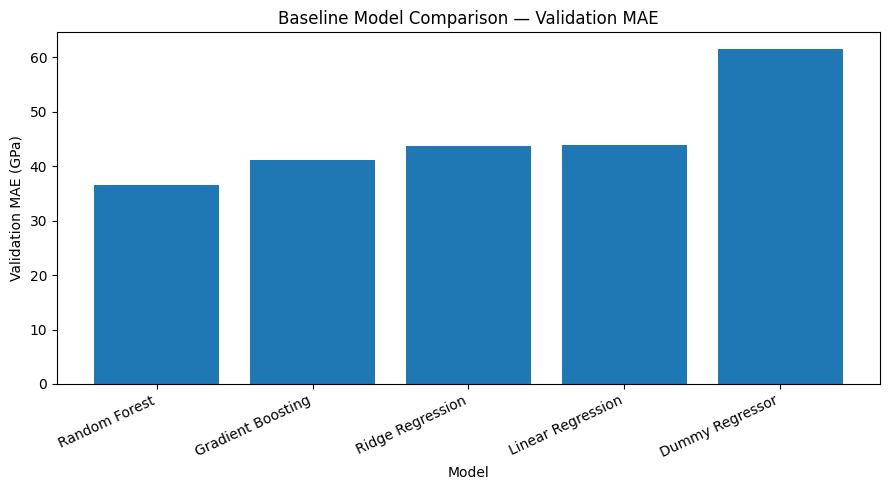

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    baseline_results["Model"],
    baseline_results["MAE"]
)

plt.ylabel("Validation MAE (GPa)")
plt.xlabel("Model")
plt.title("Baseline Model Comparison — Validation MAE")

plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plt.savefig(
    figures_dir / "baseline_model_mae.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
y_train_pred_rf = random_forest_model.predict(X_train)

rf_train_mae = mean_absolute_error(
    y_train,
    y_train_pred_rf
)

rf_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_rf
    )
)

rf_train_r2 = r2_score(
    y_train,
    y_train_pred_rf
)

print("Random Forest Performance")
print("-------------------------")
print(f"Train MAE:       {rf_train_mae:.2f} GPa")
print(f"Validation MAE:  {rf_mae:.2f} GPa")
print()
print(f"Train RMSE:      {rf_train_rmse:.2f} GPa")
print(f"Validation RMSE: {rf_rmse:.2f} GPa")
print()
print(f"Train R²:        {rf_train_r2:.3f}")
print(f"Validation R²:   {rf_r2:.3f}")

Random Forest Performance
-------------------------
Train MAE:       12.58 GPa
Validation MAE:  36.60 GPa

Train RMSE:      17.04 GPa
Validation RMSE: 50.32 GPa

Train R²:        0.945
Validation R²:   0.564


## Baseline Modeling Findings

Five baseline regression approaches were evaluated using the validation set.

### Validation Performance

| Model | MAE (GPa) | RMSE (GPa) | R² |
|---|---:|---:|---:|
| Dummy Regressor | 61.543 | 76.343 | -0.005 |
| Linear Regression | 43.926 | 59.172 | 0.397 |
| Ridge Regression | 43.695 | 58.364 | 0.413 |
| Random Forest | 36.596 | 50.319 | 0.564 |
| Gradient Boosting | 41.106 | 53.488 | 0.507 |

All predictive models substantially outperform the mean-based dummy baseline,
indicating that the selected material descriptors contain useful information
for predicting bulk modulus.

Nonlinear tree-based models outperform the linear baselines, suggesting that
the relationships between the selected descriptors and `K_VRH` are not
adequately represented by simple linear effects alone.

Among the evaluated baseline configurations, Random Forest achieved the
lowest validation error and highest validation R².

### Random Forest Generalization Check

The Random Forest showed a substantial difference between training and
validation performance:

- Training MAE: 12.58 GPa
- Validation MAE: 36.60 GPa
- Training RMSE: 17.04 GPa
- Validation RMSE: 50.32 GPa
- Training R²: 0.945
- Validation R²: 0.564

This train-validation gap indicates substantial overfitting in the default
Random Forest configuration. Therefore, the baseline result should not be
treated as the final model.

The next modeling stage should focus on improving generalization through
controlled model complexity and validation-based hyperparameter selection.

The test set remains untouched and will be reserved for final evaluation.